# Aula 03: Problemas de Transporte e Otimização em Redes

Nesta aula, exploraremos problemas onde o objetivo é movimentar bens ou informações através de uma rede de forma eficiente. Estes problemas são aplicações clássicas de Programação Linear.

## 1. O Problema de Transporte (Transportation Problem)

O problema clássico de transporte envolve um conjunto de **origens** (ex: fábricas) e um conjunto de **destinos** (ex: centros de distribuição).

- Cada origem tem uma capacidade de **oferta**.
- Cada destino tem uma necessidade de **demanda**.
- Existe um código associado ao envio de uma unidade de cada origem para cada destino.

**Objetivo**: Minimizar o custo total de transporte atendendo a todas as demandas sem exceder as ofertas.

### Modelo Matemático

**Variáveis de Decisão:**
- $x_{ij}$: Quantidade enviada da origem $i$ para o destino $j$.

**Função Objetivo:**
Minimizar $Z = \sum_{i} \sum_{j} c_{ij} x_{ij}$

**Restrições:**
1. **Oferta**: $\sum_{j} x_{ij} \leq O_i, \quad \forall i$ (Não enviar mais do que o fabricado)
2. **Demanda**: $\sum_{i} x_{ij} \geq D_j, \quad \forall j$ (Atender à necessidade do cliente)
3. **Não-negatividade**: $x_{ij} \geq 0$

## 2. Implementação e Visualização em Rede com PuLP

Vamos carregar a instância pequena e resolvê-la, gerando um gráfico que representa o fluxo entre fábricas e centros.

Status: Optimal


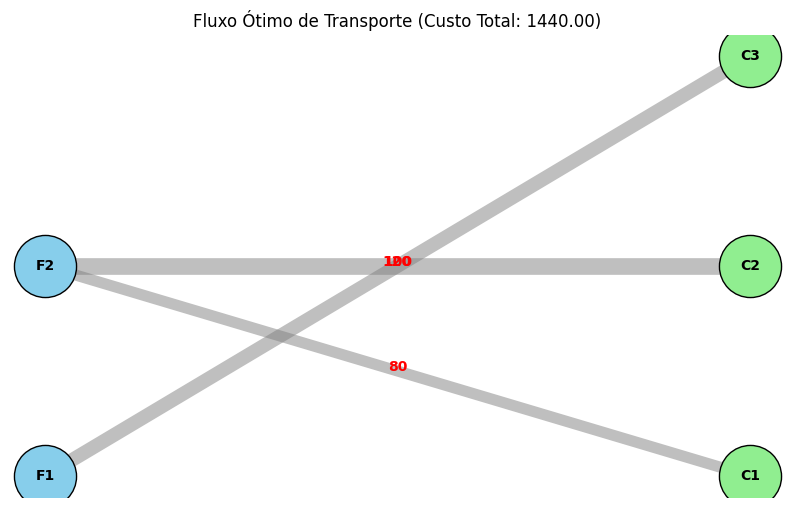

In [2]:
import pulp
import json
import matplotlib.pyplot as plt

# Carregar dados
try:
    with open('data/transporte.json', 'r') as f:
        data = json.load(f)['pequeno']
except FileNotFoundError:
    data = {
        "fabricas": ["F1", "F2"],
        "centros": ["C1", "C2", "C3"],
        "oferta": {"F1": 100, "F2": 200},
        "demanda": {"C1": 80, "C2": 120, "C3": 100},
        "custos": {
            "F1": {"C1": 4, "C2": 6, "C3": 8},
            "F2": {"C1": 2, "C2": 4, "C3": 9}
        }
    }

fabricas = data['fabricas']
centros = data['centros']
oferta = data['oferta']
demanda = data['demanda']
custos = data['custos']

# Criar o problema
prob = pulp.LpProblem("Problema_Transporte", pulp.LpMinimize)

# Variáveis
x = pulp.LpVariable.dicts("envio", (fabricas, centros), lowBound=0, cat='Continuous')

# Função Objetivo
prob += pulp.lpSum(custos[i][j] * x[i][j] for i in fabricas for j in centros)

# Restrições
for i in fabricas:
    prob += pulp.lpSum(x[i][j] for j in centros) <= oferta[i]
for j in centros:
    prob += pulp.lpSum(x[i][j] for i in fabricas) >= demanda[j]

# Resolver
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# FUNÇÃO PARA VISUALIZAÇÃO
def visualizar_transporte(fabricas, centros, x_vars):
    plt.figure(figsize=(10, 6))
    pos_f = {f: (-1, i) for i, f in enumerate(fabricas)}
    pos_c = {c: (1, i) for i, c in enumerate(centros)}
    
    # Nós
    for f, (px, py) in pos_f.items():
        plt.scatter(px, py, s=2000, c='skyblue', edgecolors='black', zorder=3)
        plt.text(px, py, f, ha='center', va='center', fontweight='bold')
    for c, (px, py) in pos_c.items():
        plt.scatter(px, py, s=2000, c='lightgreen', edgecolors='black', zorder=3)
        plt.text(px, py, c, ha='center', va='center', fontweight='bold')
        
    # Arestas (Fluxos)
    for f in fabricas:
        for c in centros:
            val = pulp.value(x_vars[f][c])
            if val > 0:
                plt.plot([pos_f[f][0], pos_c[c][0]], [pos_f[f][1], pos_c[c][1]], 
                         color='gray', lw=val/10, alpha=0.5, zorder=1)
                mid_x = (pos_f[f][0] + pos_c[c][0]) / 2
                mid_y = (pos_f[f][1] + pos_c[c][1]) / 2
                plt.text(mid_x, mid_y, str(int(val)), color='red', fontweight='bold', ha='center')
    
    plt.title(f"Fluxo Ótimo de Transporte (Custo Total: {pulp.value(prob.objective):.2f})")
    plt.axis('off')
    plt.show()

print(f"Status: {pulp.LpStatus[prob.status]}")
visualizar_transporte(fabricas, centros, x)

## 3. Alterando Custos e Restrições

Realize as seguintes modificações no código da Seção 2 e documente os resultados.

### Exercício A: Alteração de Custos
No dicionário de custos, altere o valor de `F2 -> C1` de **2** para **10**. 
- **Pergunta**: O fluxo de distribuição mudou? A fábrica F1 passou a enviar mais para C1? Por quê?

### Exercício B: Restrição de Fluxo Mínimo
Adicione uma nova restrição ao modelo que obrigue a fábrica `F1` a enviar no mínimo 50 unidades para o centro `C3` (`prob += x['F1']['C3'] >= 50`).
- **Pergunta**: Como isso afetou o custo total? O solver ainda encontrou uma solução ótima?

### Exercício C: Escassez de Oferta
Altere a oferta da fábrica `F2` para **50** (originalmente era 200). Note que agora a oferta total (100+50=150) é menor que a demanda total (80+120+100=300).
- **Pergunta**: Qual o status da solução retornado pelo solver? Por que isso acontece?


## 4. Transbordo e Escala

1. **Teste de Escala**: Tente carregar a instância `grande` do arquivo `data/transporte.json`. Note a diferença na complexidade da saída.
2. **Transbordo**: Imagine que um novo centro de distribuição intermediário foi criado. O que mudaria na conservação de fluxo das restrições para garantir que tudo o que entra nesse centro deve sair dele?